<big><big>001: data pre-processing walkthrough</big></big>
<a id='index'></a><br>

- [part 0: pre-processing for a single object](#steps)
    - alert processor
    - photometry processor
    - data preprocessor
    - [images](#images)
    - <s>[alert selection](#alert)</s>
    - [spectra](#spectra)
- [part 1: pre-processing a dataset](#transient)

In [3]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from src.data_preprocessor import AlertProcessor, PhotometryProcessor, DataPreprocessor, SpectraProcessor
from src.data_preprocessor import DataSorter
from src.transient_dataset import TransientDataset
import src.plot_data as plot_data

In [4]:
SEDM_dataset = pd.read_csv('AppleCider/SEDM_dataset.csv')
SEDM_dataset

,obj_id,type
0,ZTF18aatfxtd,SN Ia
1,ZTF18aawppyt,SN Ia
2,ZTF18aakpnyt,AGN
3,ZTF18aclgopa,AGN
4,ZTF18adjoimi,AGN
...,...,...
7493,ZTF18aajlxao,AGN
7494,ZTF18abmwqkr,AGN
7495,ZTF19aadzgnt,AGN
7496,ZTF19aaesrrd,AGN


<big>part 0: pre-processing for a single object</big>

<a id='steps'></a>


In [5]:
obj_SN = 'ZTF20aambbfn'  # other cute SN Ia: ZTF20aarasxl, ZTF20aafjjqj, ZTF22abtbijr
data_dir = 'AppleCider_Data/SEDM_folder'

# loading data from folder
# change column names, add object id, object type to make photo_df
photo_df = PhotometryProcessor.process_csv(obj_SN, SEDM_dataset, data_dir)
metadata_df, images = AlertProcessor.get_process_alerts(obj_SN, data_dir)

In [6]:
photo_df[:2]

,obj_id,jd,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF20aambbfn,2.458887e+06,58886.242130,19.611099,0.285659,6.18730,19.445999,ztfg,SN Ia
1,ZTF20aambbfn,2.458885e+06,58884.489363,19.048901,0.134265,6.29451,19.866400,ztfr,SN Ia


In [7]:
metadata_df[:2]

,jd,fid,pid,diffmaglim,pdiffimfilename,programpi,programid,candid,isdiffpos,tblid,...,clrmed,clrrms,neargaia,neargaiabright,maggaia,maggaiabright,exptime,drb,drbversion,obj_id
0,2.458885e+06,2,1130489363715,19.866436,ztf_20200205489340_000752_zr_c10_o_q2_scimrefd...,Kulkarni,3,1130489363715015004,t,4,...,0.742,0.327286,0.976307,-999.0,18.066233,-999.0,30.0,0.996355,d6_m7,ZTF20aambbfn
1,2.458887e+06,1,1132243023715,19.475851,ztf_20200207243021_000752_zg_c10_o_q2_scimrefd...,Kulkarni,1,1132243023715015001,t,1,...,0.601,0.294263,1.226615,-999.0,18.066233,-999.0,30.0,0.976252,d6_m7,ZTF20aambbfn


In [8]:
# sort by date (JD)
# add metadata missing from photometry
photo_df, metadata_df = photo_df.sort_values(by='jd'), metadata_df.sort_values(by='jd')
photo_df = PhotometryProcessor.add_metadata_to_photometry(photo_df, metadata_df)
photo_df[:2]

,obj_id,jd,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF20aambbfn,2.458885e+06,58884.489363,19.048901,0.134265,6.29451,19.866400,ztfr,SN Ia
1,ZTF20aambbfn,2.458887e+06,58886.242130,19.611099,0.285659,6.18730,19.445999,ztfg,SN Ia


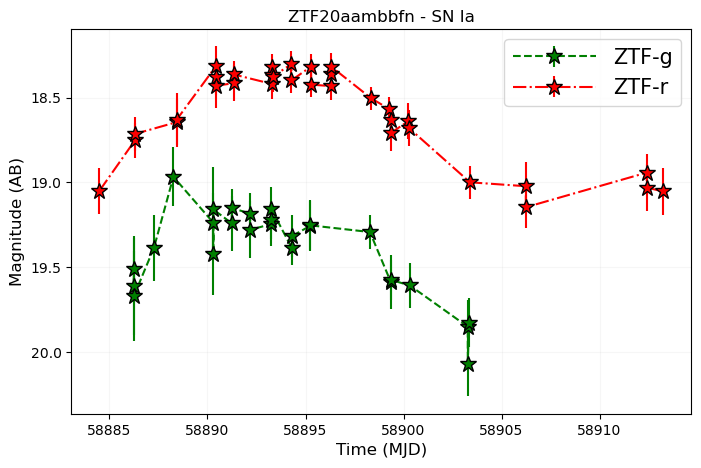

In [9]:
plot_data.plot_photometry_magnitude(photo_df)

<a id='images'></a>

55
Selected index: [ 3 28 54]
Image number: 3


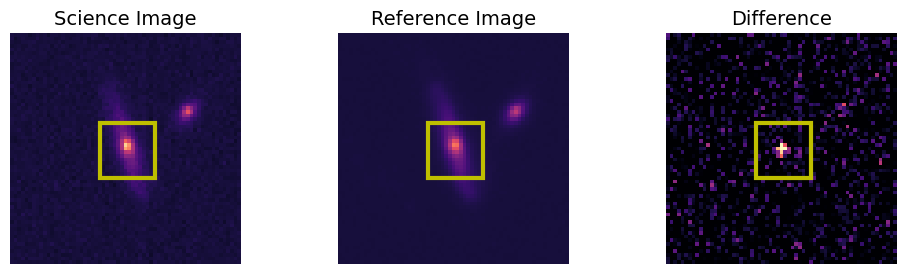

Image number: 28


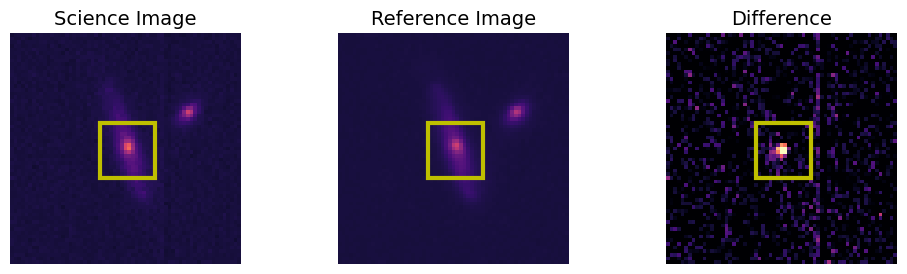

Image number: 54


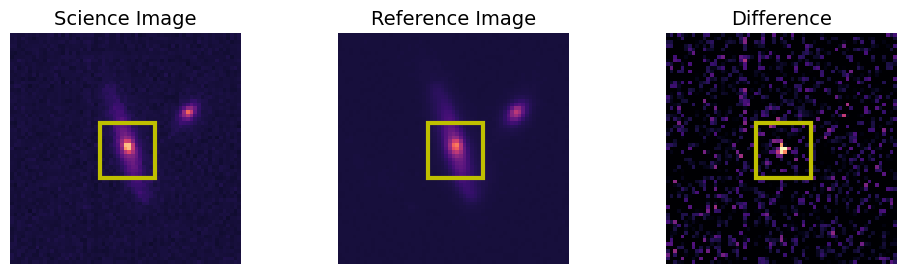

In [10]:
print(len(images))

n = 3
selected_index = np.round(np.linspace(3, len(images) - 1, n)).astype(int)
print('Selected index:', selected_index)
for i in selected_index:
    print('Image number:', i)
    plot_data.plot_image(images[i], vmin_set=0.004, vmax_set=0.099)

In [11]:
photo_df_process = DataPreprocessor.convert_photometry(photo_df)
photo_df_process[:1]

,obj_id,mjd,flux,flux_error,filter,type,jd
0,ZTF20aambbfn,0.0,87.184596,10.781477,ztfr,SN Ia,2.458885e+06


In [12]:
start_index = PhotometryProcessor.get_first_valid_index(photo_df_process)
print('Start index:', start_index)

Start index: 0


<a id='alert'></a>

In [13]:
#for i in selected_index:
#    print('Photometry at index:', i)
#    photo_ready = DataPreprocessor.cut_photometry(photo_df_process, metadata_df, i)
#    plot_data.plot_photometry_magnitude(photo_ready)

<a id='spectra'></a>

<a id='spectra'></a>

In [15]:
SpectraProcessor.get_spectra_df(obj_SN, data_dir)

,ZTFID,wavelengths,fluxes,observed_at,observed_at_mjd,instrument_name,telescope_name,data_length
0,ZTF20aambbfn,3776.7,4.792000e-17,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
1,ZTF20aambbfn,3802.3,4.812000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
2,ZTF20aambbfn,3827.9,7.101000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
3,ZTF20aambbfn,3853.4,4.830000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
4,ZTF20aambbfn,3879.0,5.129000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
...,...,...,...,...,...,...,...,...
209,ZTF20aambbfn,9121.0,1.317000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
210,ZTF20aambbfn,9146.6,1.373000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
211,ZTF20aambbfn,9172.1,1.368000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
212,ZTF20aambbfn,9197.7,1.330000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3


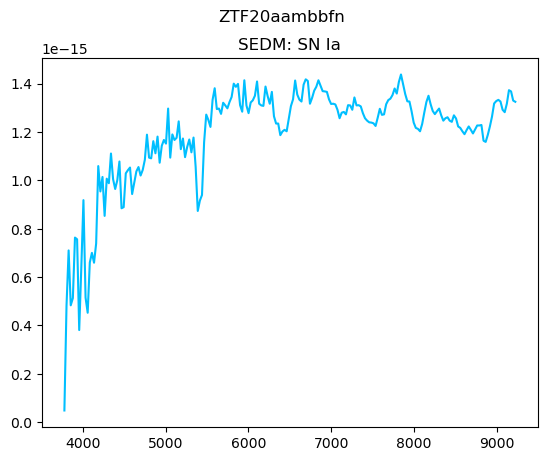

In [16]:
plot_data.plot_spectra(obj_SN, SEDM_dataset, data_dir)

In [18]:
# preprocess spectra
spectra = SpectraProcessor.read_spectra_csv(obj_SN, data_dir)
spectra = SpectraProcessor.preprocess_spectra(spectra)
spectra

array([[-5.152986  , -5.06692   , -4.9808536 , ...,  0.24690495,
         0.21799059,  0.18907624]], dtype=float32)

***

<big><big>part 1: pre-processing the dataset</big></big>

<a id='transient'></a>
<i><small>[back to index](#index)</small></i>

In [143]:
TEST_DATA_PATH = 'AppleCider_Data/sedm_data_test_2-7'
TRAIN_DATA_PATH = 'AppleCider_Data/sedm_data_train_2-7'

CLASSES = ['SN Ia', 'SN Ia-91T', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event',
           'Stellar variable']

In [148]:
test_df, train_df = DataSorter.sample_objects_from_df(SEDM_dataset, 'type', CLASSES, data_dir, n_test=1000, n_train=6000, sedm_spec_only=False, downsample_SNIa=False)

In [149]:
test_df

,obj_id,type
0,ZTF24aailzom,SN Ia
1,ZTF19aawupxb,SN Ia
2,ZTF23aaalcjc,SN Ia
3,ZTF21acefbte,SN Ia
4,ZTF19acuyvtl,SN Ia
...,...,...
1005,ZTF21aalimya,SN IIb
1006,ZTF21aaxtrlt,SN Ia-91T
1007,ZTF21abahiow,SN Ib
1008,ZTF21abrfvax,SN Ic


In [150]:
train_df

,obj_id,type
0,ZTF22abtlaew,SN Ia
1,ZTF20acoaqpm,SN Ia
2,ZTF21aarigsr,SN Ia
3,ZTF20aafwbcs,SN Ia
4,ZTF19abirbpd,SN Ia
...,...,...
5995,ZTF20abaszgh,SN Ib
5996,ZTF20abpvhlg,SN IIP
5997,ZTF19acftude,SN IIn
5998,ZTF22aabnvrz,SN Ia


In [151]:
dataset_test = TransientDataset(TEST_DATA_PATH, base_path=data_dir)
dataset_test.preprocess_data(test_df, data_dir)

dataset_test.preprocess_and_save()

Loading data:   0%|          | 0/1010 [00:00<?, ?it/s]

Processing Objects:   0%|          | 0/4829 [00:00<?, ?it/s]

In [153]:
dataset_train = TransientDataset(TRAIN_DATA_PATH, base_path=data_dir)
dataset_train.preprocess_data(train_df, data_dir)

dataset_train.preprocess_and_save()

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

Processing Objects:   0%|          | 0/28153 [00:00<?, ?it/s]

In [156]:
# make dataframe of object IDs with associated alert file names, and clasification 
data_test, data_train = DataSorter.create_df_of_object_alerts_in_dataset(test_df, train_df, TEST_DATA_PATH, TRAIN_DATA_PATH)

In [157]:
data_test

,name,file,type
0,ZTF17aadlxmv,ZTF17aadlxmv_alert_5.npy,SN Ia
1,ZTF17aadlxmv,ZTF17aadlxmv_alert_6.npy,SN Ia
2,ZTF17aadlxmv,ZTF17aadlxmv_alert_7.npy,SN Ia
3,ZTF17aadlxmv,ZTF17aadlxmv_alert_8.npy,SN Ia
4,ZTF17aadlxmv,ZTF17aadlxmv_alert_9.npy,SN Ia
...,...,...,...
4824,ZTF24abbcmal,ZTF24abbcmal_alert_2.npy,SN Ia
4825,ZTF24abbcmal,ZTF24abbcmal_alert_3.npy,SN Ia
4826,ZTF24abbcmal,ZTF24abbcmal_alert_4.npy,SN Ia
4827,ZTF24abbcrsy,ZTF24abbcrsy_alert_2.npy,SN II


In [158]:
data_train

,name,file,type
0,ZTF17aaajnki,ZTF17aaajnki_alert_1.npy,AGN
1,ZTF17aaajnki,ZTF17aaajnki_alert_2.npy,AGN
2,ZTF17aaaobyl,ZTF17aaaobyl_alert_2.npy,Cataclysmic
3,ZTF17aaaobyl,ZTF17aaaobyl_alert_3.npy,Cataclysmic
4,ZTF17aaaukqn,ZTF17aaaukqn_alert_10.npy,Cataclysmic
...,...,...,...
28148,ZTF24abbrcrq,ZTF24abbrcrq_alert_6.npy,SN Ia
28149,ZTF24abbsboo,ZTF24abbsboo_alert_3.npy,SN Ia
28150,ZTF24abbsboo,ZTF24abbsboo_alert_4.npy,SN Ia
28151,ZTF24abbsboo,ZTF24abbsboo_alert_5.npy,SN Ia


In [159]:
#data_train.to_csv('AppleCider_Data/data_train_2-7.csv', index=False)
#data_test.to_csv('AppleCider_Data/data_test_2-7.csv', index=False)

In [161]:
# example alert
np.load('/AppleCider_Data/sedm_data_train_2-7/ZTF17aaajnki_alert_1.npy', allow_pickle=True).item()

{'obj_id': 'ZTF17aaajnki',
 'photometry_ztfr': array([[  0.        , 207.37654926,   8.88879786]]),
 'photometry_ztfg': array([[0., 0., 0.]]),
 'metadata': sgscore1    -999.000000
 sgscore2    -999.000000
 distpsnr1      0.329015
 distpsnr2   -999.000000
 ra           186.453587
 dec           33.546771
 nmtchps     -999.000000
 sharpnr        0.083000
 scorr       -999.000000
 sky            0.001838
 Name: 10, dtype: float64,
 'images': array([[[1.49582508e-02, 7.00525308e-03, 2.25153227e-02],
         [4.98608359e-03, 8.40630370e-03, 2.05743466e-02],
         [1.42934396e-02, 1.01576170e-02, 2.17389322e-02],
         ...,
         [1.00000000e-09, 1.00000000e-09, 1.00000000e-09],
         [1.00000000e-09, 1.00000000e-09, 1.00000000e-09],
         [1.00000000e-09, 1.00000000e-09, 1.00000000e-09]],
 
        [[1.19666006e-02, 8.05604104e-03, 3.14438127e-02],
         [5.98330031e-03, 8.75656635e-03, 1.35868326e-02],
         [5.31848917e-03, 9.80735431e-03, 9.70488046e-03],
         .